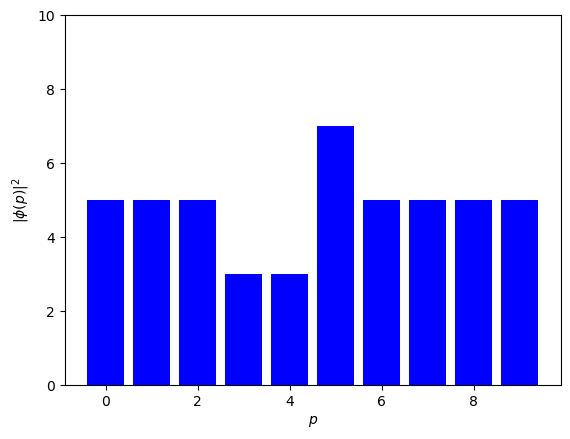

In [35]:
import ipywidgets as widgets
from ipywidgets import IntSlider
from ipywidgets import interact, interactive, fixed, interact_manual
#import IPython.display as display
#from IPython.display import display
from IPython import display

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np


ps = [x for x in range(0,10,1)]


def get_all_values(sliders):
    return [slider.value for slider in sliders]

def make_plot(hdisplay,ax,hist,ps,counts):
    for i in range(0,len(counts)):
        hist[i].set_height(counts[i])
        
    hdisplay.update(fig)
    

    

    
# Define sliders
sliders = [0]*len(ps)
for i in range(0,len(ps)):
    sliders[i] = widgets.IntSlider(value=5,min=0,max=10,orientation='vertical', description='p'+str(i))

# Arrange them side-by-side using HBox (Horizontal Box)
ui_sliders = widgets.HBox(sliders)

# Display the container
display.display(ui_sliders)
    
    
    


# Initial histogram
fig,ax = plt.subplots()
hdisplay = display.display(fig, display_id=True)
ax.set_ylim(0,10)
ax.set_ylabel(r'$|\phi(p)|^2$')
ax.set_xlabel(r'$p$')
counts = get_all_values(sliders)
hist = ax.bar(ps,counts,color="blue")
hdisplay.update(fig)


# Define update function for the 3D scatter plot
def update_plot(change):
    make_plot(hdisplay,ax,hist,ps,get_all_values(sliders))

# Attach the update function to the sliders' value change event
for slider in sliders:
    slider.observe(update_plot,'value')

plt.close()